# Dados Necessários

Este trabalho utiliza os microdados públicos da **Pesquisa Nacional de Saúde (PNS 2019)**, disponibilizados pelo Instituto Brasileiro de Geografia e Estatística (IBGE).

Os microdados **não acompanham este repositório**, pois o arquivo possui aproximadamente 445 MB e excede o limite de tamanho permitido pelo GitHub para arquivos individuais.

## Como obter os dados

Na data de elaboração deste trabalho (julho de 2026), os arquivos estavam disponíveis na página oficial do IBGE:

https://ftp.ibge.gov.br/PNS/2019/Microdados/Documentacao/

e os microdados em:

https://ftp.ibge.gov.br/PNS/2019/Microdados/

Como endereços eletrônicos podem ser alterados ao longo do tempo, recomenda-se, caso os links acima não estejam disponíveis, acessar o portal oficial do IBGE e pesquisar por:

> **Microdados PNS 2019**

Após o download:

1. Extraia o arquivo compactado;
2. Copie `PNS_2019.txt` para a pasta deste projeto;
3. Mantenha também os arquivos de layout (`input_PNS_2019.txt` e `input_PNS_2019.sas`);
4. Execute o notebook normalmente.

Caso o arquivo `PNS_2019.txt` não seja encontrado, o notebook exibirá uma mensagem informando que os microdados precisam ser adicionados ao projeto.

In [36]:
# ============================================================
# VERIFICAÇÃO DOS MICRODADOS
# ============================================================
#
# Este notebook utiliza os microdados públicos da PNS 2019.
#
# Caso o arquivo PNS_2019.txt não esteja presente na pasta do
# projeto, faça o download diretamente no portal do IBGE.
#
# Link utilizado durante o desenvolvimento deste trabalho:
#
# https://ftp.ibge.gov.br/PNS/2019/Microdados/
#
# Se o endereço for alterado, procure por:
#
# "Microdados PNS 2019 IBGE"
# ============================================================

print("✓ Verificando a existência dos microdados da PNS 2019...")

if not ARQUIVO_PNS.exists():
    raise FileNotFoundError(
        """
Arquivo PNS_2019.txt não encontrado.

Baixe os microdados da PNS 2019 no portal oficial do IBGE,
extraia o arquivo e coloque-o na mesma pasta deste notebook.

Link utilizado durante o desenvolvimento:
https://ftp.ibge.gov.br/PNS/2019/Microdados/
"""
    )

print("✓ Microdados encontrados.")

✓ Verificando a existência dos microdados da PNS 2019...
✓ Microdados encontrados.


In [ ]:
from google.colab import files

uploaded = files.upload()

Saving dicionario_PNS_microdados_2019.xls to dicionario_PNS_microdados_2019.xls
Saving input_PNS_2019.sas to input_PNS_2019.sas
Saving input_PNS_2019.txt to input_PNS_2019.txt
Saving PNS_2019.txt to PNS_2019.txt


In [ ]:
# ============================================================
# IMPORTAÇÕES
# ============================================================

from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import networkx as nx

In [ ]:
# ============================================================
# 1. CONFIGURAÇÃO DOS CAMINHOS
# ============================================================

PASTA_PROJETO = Path("/content")

ARQUIVO_PNS = PASTA_PROJETO / "PNS_2019.txt"
ARQUIVO_DICIONARIO = PASTA_PROJETO / "dicionario_PNS_microdados_2019.xls"
ARQUIVO_LAYOUT = PASTA_PROJETO / "input_PNS_2019.txt"
ARQUIVO_SAS = PASTA_PROJETO / "input_PNS_2019.sas"

PASTA_SAIDA = PASTA_PROJETO / "saida"
PASTA_SAIDA.mkdir(exist_ok=True)

print("Base:", ARQUIVO_PNS.exists())
print("Dicionário:", ARQUIVO_DICIONARIO.exists())
print("Layout:", ARQUIVO_LAYOUT.exists())
print("SAS:", ARQUIVO_SAS.exists())

Base: True
Dicionário: True
Layout: True
SAS: True


In [ ]:
# ============================================================
# 3. INSPEÇÃO DO ARQUIVO DE LAYOUT
# ============================================================

with ARQUIVO_LAYOUT.open(
    mode="r",
    encoding="latin-1",
    errors="replace"
) as arquivo:
    for numero_linha in range(20):
        linha = arquivo.readline()

        if not linha:
            break

        print(f"{numero_linha + 1:02d}: {linha.rstrip()}")

01: /* PROGRAMA DE LEITURA EM SAS DO ARQUIVO DE MICRODADOS DA PNS 2019 */
02: 
03: /* Obs.1: As duas primeiras posições da UPA_PNS (Unidade Primária de Amostragem) são o código da UF (Unidade da Federação)
04: 
05:    Obs.2: Ajuste o endereço do arquivo \PNS_2019.txt no comando INFILE */
06: 
07: 
08: data PNS_2019;
09: INFILE '...\dados\PNS_2019.txt' LRECL=1548 missover;
10: INPUT
11: @00001	V0001	$2.	 	/*Unidade da Federação*/
12: @00003	V0024	$7.		/*Estrato*/
13: @00010	UPA_PNS	$9.		/*UPA*/
14: @00019	V0006_PNS	$4.	/*Número de ordem do domicílio na PNS*/
15: @00023	V0015	$2.	 	/*Tipo da entrevista*/
16: @00025	V0020	$4.	 	/*Ano de referência*/
17: @00029	V0022	2.	 	/*Total de moradores*/
18: @00031	V0026	$1.		/*Tipo de situação censitária*/
19: @00032	V0031	$1.	 	/*Tipo de área*/
20: @00033	V0025A	$1.


In [ ]:
# ============================================================
# 4. EXTRAÇÃO AUTOMÁTICA DO LAYOUT SAS
# ============================================================

import re

registros_layout = []

padrao = re.compile(
    r"^\s*@(?P<posicao>\d+)\s+"
    r"(?P<variavel>[A-Za-z0-9_]+)\s+"
    r"(?P<texto>\$)?(?P<tamanho>\d+)\."
)

with ARQUIVO_LAYOUT.open(
    mode="r",
    encoding="latin-1",
    errors="replace"
) as arquivo:

    for linha in arquivo:
        resultado = padrao.search(linha)

        if resultado:
            registros_layout.append(
                {
                    "posicao_inicial": int(resultado.group("posicao")),
                    "variavel": resultado.group("variavel"),
                    "tamanho": int(resultado.group("tamanho")),
                    "tipo_sas": (
                        "texto"
                        if resultado.group("texto")
                        else "numerico"
                    ),
                }
            )

layout = pd.DataFrame(registros_layout)

print(f"Variáveis identificadas no layout: {len(layout)}")
display(layout.head(10))
display(layout.tail(10))

Variáveis identificadas no layout: 1088


,posicao_inicial,variavel,tamanho,tipo_sas
0,1,V0001,2,texto
1,3,V0024,7,texto
2,10,UPA_PNS,9,texto
3,19,V0006_PNS,4,texto
4,23,V0015,2,texto
5,25,V0020,4,texto
6,29,V0022,2,numerico
7,31,V0026,1,texto
8,32,V0031,1,texto
9,33,V0025A,1,texto


,posicao_inicial,variavel,tamanho,tipo_sas
1078,1516,VDE002,1,texto
1079,1517,VDE014,2,texto
1080,1519,VDF002,8,numerico
1081,1527,VDF003,8,numerico
1082,1535,VDF004,1,texto
1083,1536,VDL001,2,numerico
1084,1538,VDM001,1,texto
1085,1539,VDP001,1,texto
1086,1540,VDR001,1,texto
1087,1541,VDDATA,8,texto


In [ ]:
# ============================================================
# 5. SELEÇÃO DAS VARIÁVEIS DE INTERESSE
# ============================================================
#
# Nesta etapa criaremos uma função para selecionar automaticamente
# as variáveis desejadas a partir do layout da PNS.
#
# A função retornará:
#
# - colspecs: posições de leitura do arquivo de largura fixa;
# - names: nomes das variáveis selecionadas.
#
# Dessa forma, evitamos escrever manualmente centenas de posições
# e o código torna-se reutilizável para qualquer conjunto de
# variáveis da PNS.
# ============================================================

def selecionar_variaveis(layout, variaveis):

    layout_filtrado = (
        layout
        .loc[layout["variavel"].isin(variaveis)]
        .copy()
        .sort_values("posicao_inicial")
        .reset_index(drop=True)
    )

    colspecs = []

    for _, linha in layout_filtrado.iterrows():

        inicio = linha["posicao_inicial"] - 1
        fim = inicio + linha["tamanho"]

        colspecs.append((inicio, fim))

    nomes = layout_filtrado["variavel"].tolist()

    return layout_filtrado, colspecs, nomes

In [ ]:
# ============================================================
# 6. DEFINIÇÃO DAS VARIÁVEIS DA PESQUISA
# ============================================================
#
# Nesta etapa definimos as variáveis que serão utilizadas na
# construção da base analítica.
#
# A seleção foi feita com base na pergunta de pesquisa:
#
# "Qual é o efeito da obtenção de medicamentos pelo Programa
# Farmácia Popular sobre a adesão ao tratamento entre pessoas
# diagnosticadas com hipertensão arterial?"
#
# Para facilitar a manutenção do código, utilizamos um dicionário
# que associa cada papel analítico ao código da variável na PNS.
# ============================================================

VARIAVEIS = {

    # ------------------------------
    # Identificação
    # ------------------------------
    "uf": "V0001",
    "estrato": "V0024",
    "upa": "UPA_PNS",
    "domicilio": "V0006_PNS",

    # ------------------------------
    # Características do indivíduo
    # ------------------------------
    "sexo": "C006",
    "idade": "C008",
    "raca": "C009",

    # ------------------------------
    # Hipertensão
    # ------------------------------
    "diagnostico": "Q00201",
    "prescricao": "Q00503",
    "uso_medicamento": "Q00601",
    "farmacia_popular": "Q00801",
    "ultima_consulta": "Q01101",

    # ------------------------------
    # Variáveis de ajuste
    # ------------------------------
    "escolaridade": "VDD004A",
    "renda_per_capita": "VDF003",

    # ------------------------------
    # Peso amostral
    # ------------------------------
    "peso": "V00291",
}

print(f"Número de variáveis selecionadas: {len(VARIAVEIS)}")

for chave, valor in VARIAVEIS.items():
    print(f"{chave:20} -> {valor}")

Número de variáveis selecionadas: 15
uf                   -> V0001
estrato              -> V0024
upa                  -> UPA_PNS
domicilio            -> V0006_PNS
sexo                 -> C006
idade                -> C008
raca                 -> C009
diagnostico          -> Q00201
prescricao           -> Q00503
uso_medicamento      -> Q00601
farmacia_popular     -> Q00801
ultima_consulta      -> Q01101
escolaridade         -> VDD004A
renda_per_capita     -> VDF003
peso                 -> V00291


In [ ]:
# ============================================================
# 7. VALIDAÇÃO DAS VARIÁVEIS E PREPARAÇÃO DA LEITURA
# ============================================================
#
# Nesta etapa verificamos se todas as variáveis definidas para a
# pesquisa estão presentes no layout oficial da PNS.
#
# Em seguida, geramos automaticamente:
#
# - layout_selecionado: descrição das variáveis escolhidas;
# - colspecs: posições de leitura do arquivo de largura fixa;
# - names: nomes das colunas da base.
#
# Essa validação evita erros antes da leitura do arquivo principal.
# ============================================================

layout_selecionado, colspecs, names = selecionar_variaveis(
    layout,
    list(VARIAVEIS.values())
)

print(f"Variáveis solicitadas : {len(VARIAVEIS)}")
print(f"Variáveis encontradas : {len(layout_selecionado)}")

# Verifica se alguma variável não foi encontrada
faltantes = set(VARIAVEIS.values()) - set(layout_selecionado["variavel"])

if len(faltantes) == 0:
    print("\n✅ Todas as variáveis foram encontradas no layout.")
else:
    print("\n⚠ Variáveis não encontradas:")
    for v in sorted(faltantes):
        print(" -", v)

display(layout_selecionado)

Variáveis solicitadas : 15
Variáveis encontradas : 15

✅ Todas as variáveis foram encontradas no layout.


,posicao_inicial,variavel,tamanho,tipo_sas
0,1,V0001,2,texto
1,3,V0024,7,texto
2,10,UPA_PNS,9,texto
3,19,V0006_PNS,4,texto
4,108,C006,1,texto
5,117,C008,3,numerico
6,120,C009,1,texto
7,807,Q00201,1,texto
8,814,Q00503,1,texto
9,815,Q00601,1,texto


In [ ]:
# ============================================================
# 8. LEITURA DAS VARIÁVEIS SELECIONADAS DA PNS 2019
# ============================================================
#
# Agora leremos o arquivo de microdados da PNS 2019.
#
# Como o arquivo possui largura fixa, utilizaremos as posições
# geradas automaticamente na etapa anterior. Serão importadas
# somente as 15 variáveis necessárias para a pesquisa, reduzindo
# o uso de memória e o tempo de processamento.
#
# Nesta primeira leitura, todas as colunas serão mantidas como
# texto. Isso preserva os códigos originais e evita conversões
# automáticas inadequadas.
# ============================================================

print("Iniciando a leitura da PNS 2019...")

pns = pd.read_fwf(
    ARQUIVO_PNS,
    colspecs=colspecs,
    names=names,
    dtype="string",
    encoding="latin-1"
)

print("Leitura concluída.")
print(f"Número de observações: {len(pns):,}".replace(",", "."))
print(f"Número de variáveis: {pns.shape[1]}")

display(pns.head())

Iniciando a leitura da PNS 2019...
Leitura concluída.
Número de observações: 293.726
Número de variáveis: 15


,V0001,V0024,UPA_PNS,V0006_PNS,C006,C008,C009,Q00201,Q00503,Q00601,Q00801,Q01101,V00291,VDD004A,VDF003
0,11,1110011,110000016,0001,2,055,1,1,1,1,1,1,00368.87516575,2,00000350
1,11,1110011,110000016,0001,1,069,4,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,1,00000350
2,11,1110011,110000016,0001,1,031,2,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,5,00000350
3,11,1110011,110000016,0001,1,009,2,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,1,00000350
4,11,1110011,110000016,0001,2,006,4,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,1,00000350


In [ ]:
# ============================================================
# 9. RENOMEANDO AS VARIÁVEIS
# ============================================================
#
# Para facilitar a leitura do código, substituímos os códigos da
# PNS por nomes mais intuitivos. Essa etapa não altera os dados,
# apenas torna o notebook mais legível e facilita as análises
# posteriores.
# ============================================================

MAPA_VARIAVEIS = {
    "V0001": "uf",
    "V0024": "estrato",
    "UPA_PNS": "upa",
    "V0006_PNS": "domicilio",

    "C006": "sexo",
    "C008": "idade",
    "C009": "raca",

    "Q00201": "diagnostico_hipertensao",
    "Q00503": "prescricao_medicamento",
    "Q00601": "uso_medicamento",
    "Q00801": "farmacia_popular",
    "Q01101": "ultima_consulta",

    "V00291": "peso",
    "VDD004A": "escolaridade",
    "VDF003": "renda_per_capita"
}

pns = pns.rename(columns=MAPA_VARIAVEIS)

print("Colunas da base:")
print(list(pns.columns))

Colunas da base:
['uf', 'estrato', 'upa', 'domicilio', 'sexo', 'idade', 'raca', 'diagnostico_hipertensao', 'prescricao_medicamento', 'uso_medicamento', 'farmacia_popular', 'ultima_consulta', 'peso', 'escolaridade', 'renda_per_capita']


In [ ]:
# ============================================================
# 10. DIAGNÓSTICO DAS VARIÁVEIS
# ============================================================
#
# Antes de iniciar a limpeza dos dados, vamos inspecionar a
# distribuição das principais variáveis da pesquisa.
#
# O objetivo é identificar:
#
# - códigos utilizados pela PNS;
# - valores ausentes (NA);
# - categorias válidas;
# - possíveis códigos de não resposta.
#
# Essa etapa evita recodificações incorretas e garante que a
# interpretação das variáveis seja consistente com o dicionário
# oficial da pesquisa.
# ============================================================

variaveis_diagnostico = [
    "diagnostico_hipertensao",
    "prescricao_medicamento",
    "uso_medicamento",
    "farmacia_popular",
    "ultima_consulta",
    "sexo",
    "raca",
    "escolaridade"
]

for coluna in variaveis_diagnostico:

    print("=" * 70)
    print(coluna.upper())
    print("=" * 70)

    print(
        pns[coluna]
        .value_counts(dropna=False)
        .sort_index()
    )

    print()

DIAGNOSTICO_HIPERTENSAO
diagnostico_hipertensao
1        23851
2        64885
<NA>    204990
Name: count, dtype: Int64

PRESCRICAO_MEDICAMENTO
prescricao_medicamento
1        21451
2         1123
<NA>    271152
Name: count, dtype: Int64

USO_MEDICAMENTO
uso_medicamento
1        19594
2          246
3         1611
<NA>    272275
Name: count, dtype: Int64

FARMACIA_POPULAR
farmacia_popular
1         5538
2         2450
3        11852
<NA>    273886
Name: count, dtype: Int64

ULTIMA_CONSULTA
ultima_consulta
1        13169
2         3199
3         2148
4          612
5         3035
6          411
<NA>    271152
Name: count, dtype: Int64

SEXO
sexo
1       134442
2       144940
<NA>     14344
Name: count, dtype: Int64

RACA
raca
1        99019
2        28304
3         1698
4       148273
5         2064
9           24
<NA>     14344
Name: count, dtype: Int64

ESCOLARIDADE
escolaridade
1       25249
2       96094
3       19210
4       19354
5       59704
6       11338
7       30646
<NA>    32

**Interpretação dos resultados**

Nesta etapa verificamos a codificação das principais variáveis da PNS antes da recodificação. Essa inspeção é uma boa prática em análise de dados, pois evita assumir categorias incorretas e garante que as transformações posteriores respeitem a estrutura original da pesquisa.

In [ ]:
# ============================================================
# 11. LIMPEZA E RECODIFICAÇÃO DAS VARIÁVEIS
# ============================================================
#
# Nesta etapa transformaremos os códigos originais da PNS em
# variáveis mais intuitivas para a análise.
#
# As variáveis numéricas serão convertidas para seus tipos
# apropriados e serão criadas versões recodificadas das
# variáveis de tratamento e desfecho.
#
# Os códigos originais serão preservados para garantir a
# rastreabilidade da base.
# ============================================================

# ------------------------------------------------------------
# Conversão das variáveis numéricas
# ------------------------------------------------------------

variaveis_numericas = [
    "idade",
    "peso",
    "renda_per_capita"
]

for coluna in variaveis_numericas:
    pns[coluna] = pd.to_numeric(
        pns[coluna],
        errors="coerce"
    )

# ------------------------------------------------------------
# Tratamento
# Farmácia Popular
# ------------------------------------------------------------

# 1 = Todos
# 2 = Alguns
# 3 = Nenhum

pns["tratamento_farmacia_popular"] = (
    pns["farmacia_popular"]
    .map({
        "1": 1,
        "2": 1,
        "3": 0
    })
)

# ------------------------------------------------------------
# Desfecho
# Uso do medicamento
# ------------------------------------------------------------

# 1 = Todos
# 2 = Alguns
# 3 = Nenhum

pns["adesao_medicamentosa"] = (
    pns["uso_medicamento"]
    .map({
        "1": 1,
        "2": 1,
        "3": 0
    })
)

print("Conversão concluída.")

display(
    pns[
        [
            "farmacia_popular",
            "tratamento_farmacia_popular",
            "uso_medicamento",
            "adesao_medicamentosa",
            "idade",
            "peso",
            "renda_per_capita"
        ]
    ].head()
)

Conversão concluída.


,farmacia_popular,tratamento_farmacia_popular,uso_medicamento,adesao_medicamentosa,idade,peso,renda_per_capita
0,1,1.0,1,1.0,55,368.875166,350
1,<NA>,NaN,<NA>,NaN,69,<NA>,350
2,<NA>,NaN,<NA>,NaN,31,<NA>,350
3,<NA>,NaN,<NA>,NaN,9,<NA>,350
4,<NA>,NaN,<NA>,NaN,6,<NA>,350


#**Interpretação das variáveis selecionadas**

Nesta etapa apresentamos as variáveis selecionadas da Pesquisa Nacional de Saúde (PNS 2019), descrevendo a pergunta realizada ao entrevistado, todas as categorias de resposta previstas no dicionário oficial do IBGE e a forma como cada variável será utilizada nesta pesquisa.

O objetivo desta documentação é tornar a construção da base analítica totalmente transparente e permitir que qualquer leitor compreenda a origem de cada informação utilizada na análise.

##**Variáveis de identificação da pesquisa**

Estas variáveis identificam a localização da entrevista e a estrutura amostral da PNS. Elas não representam características dos entrevistados, mas são importantes para identificar corretamente cada observação e considerar o desenho amostral da pesquisa.

**V0001 – Unidade da Federação**

Identifica a Unidade da Federação onde a entrevista foi realizada.

Categorias possíveis:

Código	Significado

- 11	- Rondônia

- 12	- Acre

- 13	- Amazonas

- 14	- Roraima

- 15	- Pará

- 16	- Amapá

- 17	- Tocantins

- 21	- Maranhão

- 22	- Piauí

- 23	- Ceará

- 24	- Rio Grande do Norte

- 25	- Paraíba

- 26	- Pernambuco

- 27	- Alagoas

- 28	- Sergipe

- 29	- Bahia

- 31	- Minas Gerais

- 32	- Espírito Santo

- 33	- Rio de Janeiro

- 35	- São Paulo

- 41	- Paraná

- 42	- Santa Catarina

- 43	- Rio Grande do Sul

- 50	- Mato Grosso do Sul

- 51	- Mato Grosso

- 52	- Goiás

- 53	- Distrito Federal


**V0024 – Estrato**

Identifica o estrato amostral utilizado no plano de amostragem da PNS.

Essa variável será preservada na base para possibilitar análises que considerem o desenho complexo da pesquisa.

**UPA_PNS – Unidade Primária de Amostragem (UPA)**

Identifica a Unidade Primária de Amostragem.

Também faz parte do desenho amostral da pesquisa.

**V0006_PNS – Número de ordem do domicílio**

Identifica o domicílio selecionado dentro da Unidade Primária de Amostragem.

**Características sociodemográficas**
**C006 – Sexo**

Pergunta realizada:

**Sexo do morador.**

Categorias possíveis:

Código	Significado

- 1	- Homem

- 2	- Mulher

Esta variável será utilizada como potencial variável de ajuste (confundidor).

**C008 – Idade**

Pergunta realizada:

Idade do morador na data de referência.

Categorias possíveis:

- Valores entre 0 e 130 anos.

Será utilizada como variável contínua.

**C009 – Cor ou raça**

Pergunta realizada:

Cor ou raça.

Categorias possíveis:

Código	Significado

- 1	- Branca

- 2	- Preta

- 3	- Amarela

- 4	- Parda

- 5	- Indígena

- 9	- Ignorado

Será utilizada como variável de controle.

Variáveis relacionadas à hipertensão arterial

Essas variáveis representam o núcleo da análise causal deste trabalho.

**Q00201 – Diagnóstico de hipertensão arterial**

Pergunta realizada:

"Algum médico já lhe deu o diagnóstico de hipertensão arterial (pressão alta)?"

Categorias possíveis:

Código	Significado:

- 1	- Sim

- 2	- Não

- 9	- Ignorado

- NA -	Não aplicável

Nesta pesquisa, apenas indivíduos com resposta "Sim" serão considerados elegíveis para a população de estudo.

**Q00503 – Prescrição de medicamento**

Pergunta realizada:

"Algum médico já lhe receitou algum medicamento para a hipertensão arterial (pressão alta)?"

Categorias possíveis:

Código	Significado
- 1	- Sim
- 2	- Não
- 9	- Ignorado
- NA	- Não aplicável

Esta variável será utilizada para restringir a análise aos indivíduos que possuem indicação médica para tratamento medicamentoso.

**Q00601 – Uso de medicamentos para hipertensão**

Pergunta realizada:

"Nas duas últimas semanas, o(a) Sr.(a) tomou os medicamentos para controlar a hipertensão arterial (pressão alta)?"

Categorias possíveis:

Código	Significado
- 1	- Sim, todos
- 2	- Sim, alguns
- 3	- Não, nenhum
- 9	- Ignorado
- NA	- Não aplicável
Decisão metodológica adotada

Para fins desta pesquisa foi criada uma variável denominada adesão medicamentosa, definida da seguinte forma:

Resposta original	Nova categoria:
- Sim, todos	Aderente
- Sim, alguns	Aderente
- Não, nenhum	Não aderente

O agrupamento das respostas "Sim, todos" e "Sim, alguns" busca representar qualquer utilização do medicamento prescrito nas duas semanas anteriores à entrevista.

**Q00801 – Obtenção de medicamentos pelo Programa Farmácia Popular**

Pergunta realizada:

"Algum dos medicamentos para hipertensão arterial foi obtido no 'Aqui Tem Farmácia Popular'?"

Categorias possíveis:

Código	Significado
- 1	- Sim, todos
- 2	- Sim, alguns
- 3	- Não, nenhum
- 9	- Ignorado
- NA	- Não aplicável

Decisão metodológica adotada

Foi criada a variável tratamento, definida da seguinte forma:

Resposta original	Nova categoria:

- Sim, todos	Recebeu medicamentos pelo Programa Farmácia Popular
- Sim, alguns	Recebeu medicamentos pelo Programa Farmácia Popular
- Não, nenhum	Não recebeu medicamentos pelo Programa Farmácia Popular

O agrupamento das respostas "Sim, todos" e "Sim, alguns" permite representar a exposição ao Programa Farmácia Popular, independentemente da quantidade de medicamentos obtidos.

**Q01101 – Última consulta por hipertensão**

Pergunta realizada:

"Quando foi a última vez que o(a) Sr.(a) recebeu atendimento médico por causa da hipertensão arterial?"

Categorias possíveis:

Código	Significado
- 1	- Menos de 6 meses
- 2	- De 6 meses a menos de 1 ano
- 3	- De 1 ano a menos de 2 anos
- 4	- De 2 anos a menos de 3 anos
- 5	- 3 anos ou mais
- 6	- Nunca
- 9	- Ignorado
- NA	- Não aplicável

Essa variável poderá ser utilizada em análises exploratórias relacionadas ao acompanhamento clínico dos indivíduos.

**Variáveis de ajuste**
**VDD004A – Escolaridade**

Representa o maior nível de instrução alcançado.

Categorias possíveis:

Código	Significado
- 1	- Sem instrução
- 2	- Fundamental incompleto
- 3	- Fundamental completo
- 4	- Médio incompleto
- 5	- Médio completo
- 6	- Superior incompleto
- 7	- Superior completo
- NA	- Não aplicável

Será utilizada como potencial variável de confusão.

**VDF003 – Rendimento domiciliar per capita**

Representa o rendimento domiciliar per capita do entrevistado.

O valor é informado em reais (R$).

Será utilizada como variável contínua para representar a condição socioeconômica dos indivíduos.

**V00291 – Peso amostral**

Representa o peso amostral calibrado do morador selecionado.

Essa variável será preservada para permitir que as estimativas respeitem o plano amostral da Pesquisa Nacional de Saúde.

##**Considerações metodológicas**

Todas as definições das variáveis e de suas categorias foram extraídas do dicionário oficial dos microdados da Pesquisa Nacional de Saúde (PNS 2019).

As variáveis originais foram preservadas exatamente como disponibilizadas pelo IBGE. As variáveis "tratamento" e "adesão medicamentosa" foram criadas exclusivamente para esta pesquisa, por meio do agrupamento de categorias da PNS. Essas recodificações constituem decisões metodológicas do pesquisador e têm como finalidade adequar os microdados ao problema de pesquisa proposto: estimar o efeito da obtenção de medicamentos pelo Programa Farmácia Popular sobre a adesão ao tratamento medicamentoso entre indivíduos diagnosticados com hipertensão arterial.

In [ ]:
# ============================================================
# 12. CONSTRUÇÃO DA POPULAÇÃO ANALÍTICA
# ============================================================
#
# A PNS investiga diversos temas relacionados à saúde da população.
# Entretanto, a presente pesquisa tem como objetivo analisar apenas
# indivíduos diagnosticados com hipertensão arterial que receberam
# prescrição médica para tratamento medicamentoso.
#
# Nesta etapa construiremos a população analítica utilizada nas
# análises subsequentes.
#
# Em cada filtro será apresentada a quantidade de indivíduos
# remanescentes, permitindo documentar o processo de seleção da
# amostra.
# ============================================================

print("=" * 70)
print("POPULAÇÃO ANALÍTICA")
print("=" * 70)

print(f"População original da PNS: {len(pns):,}".replace(",", "."))

# ------------------------------------------------------------
# 1º filtro
# Diagnóstico de hipertensão
# ------------------------------------------------------------

base = pns.loc[
    pns["diagnostico_hipertensao"] == "1"
].copy()

print(
    f"Após selecionar indivíduos com diagnóstico de hipertensão: "
    f"{len(base):,}".replace(",", ".")
)

# ------------------------------------------------------------
# 2º filtro
# Prescrição médica
# ------------------------------------------------------------

base = base.loc[
    base["prescricao_medicamento"] == "1"
].copy()

print(
    f"Após selecionar indivíduos com prescrição de medicamento: "
    f"{len(base):,}".replace(",", ".")
)

print("=" * 70)

POPULAÇÃO ANALÍTICA
População original da PNS: 293.726
Após selecionar indivíduos com diagnóstico de hipertensão: 23.851
Após selecionar indivíduos com prescrição de medicamento: 21.451


### **Construção da população analítica**

A população original da PNS 2019 é composta por 293.726 indivíduos entrevistados.

Como o objetivo desta pesquisa é avaliar o efeito da obtenção de medicamentos pelo Programa Farmácia Popular sobre a adesão ao tratamento medicamentoso entre pessoas com hipertensão arterial, foram aplicados dois critérios de elegibilidade:

1. possuir diagnóstico médico de hipertensão arterial;
2. possuir prescrição médica de medicamento para hipertensão.

Após a aplicação desses critérios, a população analítica utilizada nas análises passou a ser composta por **21.451 indivíduos**.

In [ ]:
# ============================================================
# 13. ESTATÍSTICAS DESCRITIVAS DA POPULAÇÃO ANALÍTICA
# ============================================================
#
# Nesta etapa apresentaremos uma descrição da população analítica.
#
# O objetivo é caracterizar os indivíduos incluídos no estudo,
# descrevendo variáveis demográficas, socioeconômicas e aquelas
# relacionadas ao tratamento e ao desfecho de interesse.
#
# Essas informações são importantes para compreender o perfil da
# amostra antes da realização das análises causais.
# ============================================================

print("=" * 70)
print("ESTATÍSTICAS DESCRITIVAS")
print("=" * 70)

# ------------------------------------------------------------
# Variáveis numéricas
# ------------------------------------------------------------

print("\nIDADE")
print(base["idade"].describe())

print("\nRENDA PER CAPITA")
print(base["renda_per_capita"].describe())

# ------------------------------------------------------------
# Variáveis categóricas
# ------------------------------------------------------------

variaveis = [
    "sexo",
    "raca",
    "escolaridade",
    "tratamento_farmacia_popular",
    "adesao_medicamentosa"
]

for coluna in variaveis:

    print("\n" + "="*50)
    print(coluna.upper())
    print("="*50)

    frequencia = (
        base[coluna]
        .value_counts(dropna=False)
        .to_frame("Frequência")
    )

    frequencia["Percentual (%)"] = (
        frequencia["Frequência"] /
        frequencia["Frequência"].sum() * 100
    ).round(2)

    display(frequencia)

ESTATÍSTICAS DESCRITIVAS

IDADE
count      21451.0
mean     61.003823
std      13.757676
min           15.0
25%           52.0
50%           62.0
75%           71.0
max          104.0
Name: idade, dtype: Float64

RENDA PER CAPITA
count        21449.0
mean     1805.619096
std      3429.564624
min              0.0
25%            665.0
50%            999.0
75%           1863.0
max         203196.0
Name: renda_per_capita, dtype: Float64

SEXO


,Frequência,Percentual (%)
sexo,,
2,12709,59.25
1,8742,40.75



RACA


,Frequência,Percentual (%)
raca,,
4,10090,47.04
1,8343,38.89
2,2701,12.59
3,175,0.82
5,142,0.66



ESCOLARIDADE


,Frequência,Percentual (%)
escolaridade,,
2,9093,42.39
5,3851,17.95
1,3208,14.96
7,2564,11.95
3,1591,7.42
4,746,3.48
6,398,1.86



TRATAMENTO_FARMACIA_POPULAR


,Frequência,Percentual (%)
tratamento_farmacia_popular,,
0.0,11852,55.25
1.0,7988,37.24
NaN,1611,7.51



ADESAO_MEDICAMENTOSA


,Frequência,Percentual (%)
adesao_medicamentosa,,
1.0,19840,92.49
0.0,1611,7.51


In [ ]:
# ============================================================
# 14. VERIFICAÇÃO DA CONSISTÊNCIA DOS DADOS
# ============================================================
#
# Antes das análises causais, verificaremos a consistência entre
# as respostas sobre uso de medicamentos e obtenção de
# medicamentos pelo Programa Farmácia Popular.
#
# Essa etapa permite identificar se os valores ausentes observados
# decorrem da lógica de aplicação do questionário ou de possíveis
# inconsistências nos dados.
# ============================================================

tabela = pd.crosstab(
    base["uso_medicamento"],
    base["farmacia_popular"],
    dropna=False,
    margins=True
)

display(tabela)

farmacia_popular,1,2,3,<NA>,All
uso_medicamento,,,,,
1,5502,2410,11682,0,19594
2,36,40,170,0,246
3,0,0,0,1611,1611
All,5538,2450,11852,0,21451


# Formulação do problema causal

## Política pública analisada

A política pública selecionada é o **Programa Farmácia Popular do Brasil**, especificamente a obtenção de medicamentos anti-hipertensivos por meio da modalidade identificada na PNS 2019 como **“Aqui Tem Farmácia Popular”**.

O programa busca ampliar o acesso da população a medicamentos essenciais, inclusive aqueles destinados ao tratamento da hipertensão arterial.

## Pergunta causal

> Qual é o efeito da obtenção de medicamentos anti-hipertensivos pelo Programa Farmácia Popular sobre a adesão ao tratamento medicamentoso entre pessoas diagnosticadas com hipertensão arterial e com prescrição médica?

A pergunta possui natureza causal porque não busca apenas comparar indivíduos que utilizaram ou não o programa. O objetivo é compreender o que ocorreria com a adesão medicamentosa caso uma mesma população tivesse acesso ao Farmácia Popular, em comparação com uma situação contrafactual em que não tivesse esse acesso.

## População de interesse

A população de interesse é composta por indivíduos que:

1. possuem diagnóstico médico de hipertensão arterial; e
2. receberam prescrição médica de medicamento para o controle da hipertensão.

Na base da PNS 2019, esses critérios correspondem às seguintes variáveis:

- `Q00201 = 1`: recebeu diagnóstico médico de hipertensão arterial;
- `Q00503 = 1`: recebeu prescrição médica de medicamento para hipertensão.

Após a aplicação dos critérios, a população analítica foi composta por **21.451 indivíduos**.

## Unidade de análise

A unidade de análise é o **morador selecionado para responder ao questionário individual da PNS 2019**.

## Tratamento

O tratamento causal é definido como:

\[
T_i =
\begin{cases}
1, & \text{se o indivíduo obteve todos ou alguns medicamentos pelo Farmácia Popular;}\\
0, & \text{se não obteve nenhum medicamento pelo programa.}
\end{cases}
\]

A variável foi construída a partir de `Q00801`, cujas categorias originais são:

- 1 — Sim, todos;
- 2 — Sim, alguns;
- 3 — Não, nenhum.

Assim, os códigos 1 e 2 foram agrupados na categoria “tratado”, enquanto o código 3 foi classificado como “não tratado”.

## Desfecho

O desfecho de interesse é a **adesão ao tratamento medicamentoso para hipertensão arterial nas duas semanas anteriores à entrevista**.

A variável foi construída a partir de `Q00601`, cujas categorias originais são:

- 1 — Sim, todos;
- 2 — Sim, alguns;
- 3 — Não, nenhum.

Para esta análise, definiu-se:

\[
Y_i =
\begin{cases}
1, & \text{se o indivíduo tomou todos ou alguns dos medicamentos;}\\
0, & \text{se não tomou nenhum medicamento.}
\end{cases}
\]

Essa recodificação representa qualquer utilização do medicamento prescrito como adesão, ainda que parcial.

# Quadro de resultados potenciais

No modelo de resultados potenciais, cada indivíduo possui dois resultados possíveis:

\[
Y_i(1)
\]

representa a adesão medicamentosa do indivíduo \(i\) caso ele obtenha medicamentos pelo Programa Farmácia Popular.

\[
Y_i(0)
\]

representa a adesão medicamentosa do mesmo indivíduo caso ele não obtenha medicamentos pelo programa.

O efeito causal individual seria:

\[
\tau_i = Y_i(1) - Y_i(0)
\]

Entretanto, para cada indivíduo, somente um dos resultados potenciais pode ser observado:

\[
Y_i = T_iY_i(1) + (1-T_i)Y_i(0)
\]

Se o indivíduo utilizou o Farmácia Popular, observa-se \(Y_i(1)\), mas não se observa qual seria sua adesão sem o programa. Se não utilizou o programa, observa-se \(Y_i(0)\), mas não se observa qual seria sua adesão caso tivesse obtido os medicamentos pelo programa.

Essa impossibilidade de observar simultaneamente \(Y_i(1)\) e \(Y_i(0)\) para a mesma pessoa constitui o **problema fundamental da inferência causal**.

## Comparação observada e efeito causal

A diferença observada entre tratados e não tratados pode ser escrita como:

\[
E[Y \mid T=1] - E[Y \mid T=0]
\]

Essa diferença não representa necessariamente o efeito causal do programa, porque os indivíduos que obtêm medicamentos pelo Farmácia Popular podem diferir sistematicamente daqueles que não utilizam o programa.

Características como renda, escolaridade, idade, local de residência, acesso aos serviços de saúde e gravidade da hipertensão podem influenciar simultaneamente:

- a probabilidade de utilização do Farmácia Popular; e
- a adesão ao tratamento medicamentoso.

Consequentemente, a diferença observada pode combinar o efeito do programa com **viés de seleção**.

## Limitação empírica da PNS 2019

A análise da lógica do questionário mostrou que a variável `Q00801`, referente à obtenção de medicamentos pelo Farmácia Popular, não foi aplicada aos indivíduos que declararam não ter tomado nenhum medicamento nas duas semanas anteriores à entrevista.

Assim, os 1.611 indivíduos classificados como não aderentes apresentam valor não aplicável na variável de tratamento.

Essa característica impede que a PNS 2019, isoladamente, seja utilizada para estimar diretamente o efeito causal do Farmácia Popular sobre a adesão medicamentosa sem hipóteses adicionais ou outra estratégia de mensuração.

Apesar dessa limitação, as variáveis da PNS são úteis para:

- documentar a população de interesse;
- demonstrar a operacionalização dos conceitos;
- apoiar a construção do DAG;
- discutir confundidores, mediadores e colisores;
- aplicar conceitualmente o quadro de resultados potenciais e o critério de backdoor.

Portanto, o exercício será tratado principalmente como uma proposta de identificação causal, conforme solicitado na atividade, e não como uma estimativa definitiva do efeito do programa.

# Estimando de interesse

## Escolha do estimando

A atividade solicita a descrição de um estimando de interesse (ATE, ATT ou ATU). Considerando a pergunta de pesquisa proposta, optou-se pelo Average Treatment Effect on the Treated (ATT), por ser o estimando que melhor representa o objetivo de avaliar o efeito do Programa Farmácia Popular entre os indivíduos que efetivamente utilizaram essa política pública. As definições de ATE e ATU são apresentadas apenas para contextualizar essa escolha metodológica.

O estimando selecionado para esta análise é o **Efeito Médio do Tratamento sobre os Tratados**, conhecido como **ATT** (*Average Treatment Effect on the Treated*).

O ATT representa o efeito médio da política entre os indivíduos que efetivamente receberam o tratamento, isto é, entre aqueles que obtiveram todos ou alguns de seus medicamentos anti-hipertensivos por meio do Programa Farmácia Popular.

Formalmente:

\[
ATT = E\left[Y_i(1)-Y_i(0)\mid T_i=1\right]
\]

em que:

- \(T_i=1\) indica que o indivíduo obteve medicamentos pelo Programa Farmácia Popular;
- \(Y_i(1)\) representa sua adesão medicamentosa sob utilização do programa;
- \(Y_i(0)\) representa a adesão que esse mesmo indivíduo apresentaria caso não tivesse obtido medicamentos pelo programa.

## Interpretação substantiva

No contexto desta pesquisa, o ATT responde à seguinte pergunta:

> Entre os indivíduos hipertensos que efetivamente obtiveram medicamentos pelo Programa Farmácia Popular, qual foi, em média, o efeito do programa sobre a adesão ao tratamento medicamentoso?

O componente observado para os tratados é:

\[
E[Y_i(1)\mid T_i=1]
\]

porque é possível observar a adesão dos indivíduos que utilizaram o programa.

O componente contrafactual é:

\[
E[Y_i(0)\mid T_i=1]
\]

que representa a adesão que esses mesmos indivíduos teriam apresentado caso não tivessem obtido medicamentos pelo Farmácia Popular.

Esse segundo componente não é diretamente observável e precisa ser estimado com base em indivíduos não tratados que sejam comparáveis aos tratados em relação às características anteriores ao tratamento.

## Por que utilizar o ATT?

A escolha do ATT é apropriada por três razões principais.

Primeiramente, o interesse da política pública está diretamente relacionado aos beneficiários que efetivamente utilizaram o Programa Farmácia Popular. Assim, o estimando permite avaliar se o programa produziu efeitos sobre o público alcançado.

Em segundo lugar, estimar o efeito médio para toda a população elegível por meio do ATE exigiria construir resultados contrafactuais também para indivíduos que não utilizaram o programa, inclusive para perfis que podem apresentar baixa probabilidade de participação. Isso aumentaria as exigências de comparabilidade e suporte comum.

Em terceiro lugar, o ATT possui interpretação gerencial direta: permite avaliar os benefícios produzidos para os usuários efetivos da política e subsidiar decisões relacionadas à manutenção, ao aperfeiçoamento ou à ampliação do programa.

## Por que não escolher o ATE?

O **Efeito Médio do Tratamento**, ou ATE, seria definido como:

\[
ATE = E\left[Y_i(1)-Y_i(0)\right]
\]

Esse estimando responderia à pergunta:

> Qual seria o efeito médio da obtenção de medicamentos pelo Farmácia Popular sobre toda a população elegível de indivíduos hipertensos com prescrição médica?

Embora relevante para uma eventual universalização do programa, o ATE não é o estimando principal deste trabalho porque inclui tanto usuários efetivos quanto pessoas que não utilizaram a política.

A identificação do ATE exigiria que fosse possível estimar adequadamente os dois resultados potenciais para toda a população, inclusive para indivíduos com características muito distintas daquelas observadas entre os usuários do programa.

## Por que não escolher o ATU?

O **Efeito Médio do Tratamento sobre os Não Tratados**, ou ATU, seria definido como:

\[
ATU = E\left[Y_i(1)-Y_i(0)\mid T_i=0\right]
\]

Esse estimando responderia à pergunta:

> Entre os indivíduos que não utilizaram o Farmácia Popular, qual seria o efeito médio sobre a adesão caso passassem a obter medicamentos pelo programa?

O ATU seria especialmente relevante para avaliar uma expansão da política entre pessoas ainda não atendidas. Entretanto, esse não é o foco principal desta análise, que busca compreender o efeito entre os beneficiários efetivamente alcançados.

## Condições necessárias para identificação do ATT

Para identificar o ATT por meio de dados observacionais, seriam necessárias algumas hipóteses.

### Consistência

O resultado observado deve corresponder ao resultado potencial associado ao tratamento efetivamente recebido:

\[
Y_i = Y_i(T_i)
\]

Isso pressupõe que o tratamento esteja claramente definido. Neste estudo, o tratamento corresponde à obtenção de todos ou alguns medicamentos anti-hipertensivos pelo Programa Farmácia Popular.

### Ausência de interferência

O tratamento recebido por um indivíduo não deve alterar diretamente o resultado de outro indivíduo.

Essa hipótese faz parte da condição de SUTVA (*Stable Unit Treatment Value Assumption*). No contexto analisado, pressupõe-se que a obtenção de medicamentos por uma pessoa não altere diretamente a adesão medicamentosa de outra.

### Ignorabilidade condicional

Após o controle adequado dos confundidores observados \(X\), a atribuição do tratamento deve ser independente dos resultados potenciais:

\[
\{Y_i(1),Y_i(0)\}\perp T_i \mid X_i
\]

Essa hipótese significa que, condicionando-se às variáveis necessárias para bloquear os caminhos de backdoor, os indivíduos tratados e não tratados poderiam ser considerados comparáveis.

### Positividade

Para cada combinação relevante de confundidores, deve existir probabilidade positiva de receber e de não receber o tratamento:

\[
0<P(T_i=1\mid X_i)<1
\]

Essa condição garante a existência de indivíduos tratados e não tratados comparáveis dentro dos diferentes perfis da população.

## Relação com o critério de backdoor

A identificação do ATT dependerá da seleção adequada das variáveis de ajuste.

O conjunto de ajuste deverá:

1. bloquear todos os caminhos não causais entre o Programa Farmácia Popular e a adesão medicamentosa;
2. incluir os confundidores comuns ao tratamento e ao desfecho;
3. não incluir mediadores, caso o interesse seja o efeito total da política;
4. não incluir colisores, pois seu condicionamento pode abrir caminhos espúrios.

A definição dessas variáveis será realizada por meio de um Grafo Acíclico Direcionado (DAG).

## Limitação da mensuração na PNS 2019

Embora o ATT seja o estimando conceitualmente mais adequado, sua estimação direta com a base construída apresenta uma limitação importante.

A pergunta sobre obtenção de medicamentos pelo Farmácia Popular não foi aplicada aos indivíduos que declararam não ter tomado nenhum medicamento nas duas semanas anteriores à entrevista. Consequentemente, o tratamento não é observado para parte dos indivíduos classificados como não aderentes.

Essa lógica do questionário gera uma dependência entre a observação do tratamento e o desfecho, dificultando a construção adequada do grupo contrafactual.

Por esse motivo, neste exercício o ATT será utilizado como **estimando causal de interesse**, mas não será interpretado como empiricamente identificado apenas com as variáveis disponíveis na PNS 2019.

A principal contribuição da base será apoiar a definição da população, a operacionalização dos conceitos e a construção da estratégia causal por meio do DAG e do critério de backdoor.

# História causal que fundamenta o DAG

## Mecanismo causal principal

O Programa Farmácia Popular procura ampliar o acesso da população a medicamentos considerados essenciais, inclusive medicamentos utilizados no controle da hipertensão arterial.

A hipótese causal central deste estudo é que a obtenção de medicamentos anti-hipertensivos pelo Programa Farmácia Popular pode aumentar a adesão ao tratamento ao reduzir barreiras financeiras e facilitar o acesso contínuo aos medicamentos prescritos.

A história causal principal pode ser representada da seguinte forma:

\[
\text{Farmácia Popular}
\longrightarrow
\text{maior acesso e disponibilidade de medicamentos}
\longrightarrow
\text{maior adesão medicamentosa}
\]

Nesse mecanismo, a utilização do Programa Farmácia Popular representa o tratamento, enquanto a adesão ao tratamento medicamentoso representa o desfecho.

## Tratamento

O tratamento \(T\) corresponde à obtenção de todos ou de parte dos medicamentos anti-hipertensivos por meio do Programa Farmácia Popular.

\[
T =
\begin{cases}
1, & \text{se obteve todos ou alguns medicamentos pelo programa;}\\
0, & \text{se não obteve nenhum medicamento pelo programa.}
\end{cases}
\]

## Desfecho

O desfecho \(Y\) corresponde ao uso dos medicamentos prescritos para o controle da hipertensão nas duas semanas anteriores à entrevista.

\[
Y =
\begin{cases}
1, & \text{se tomou todos ou alguns dos medicamentos;}\\
0, & \text{se não tomou nenhum medicamento.}
\end{cases}
\]

## Mediador

O mediador proposto é a **disponibilidade regular do medicamento para o indivíduo**, também interpretada como redução das barreiras financeiras e materiais de acesso.

A lógica causal é:

\[
T \longrightarrow M \longrightarrow Y
\]

em que:

- \(T\) representa a obtenção de medicamentos pelo Farmácia Popular;
- \(M\) representa a disponibilidade regular ou a maior acessibilidade ao medicamento;
- \(Y\) representa a adesão medicamentosa.

O programa pode reduzir o custo direto do medicamento e facilitar sua obtenção. Essa maior disponibilidade pode, por sua vez, aumentar a probabilidade de o indivíduo utilizar o medicamento conforme prescrito.

Como o objetivo é estimar o **efeito total** do programa sobre a adesão, o mediador não deve ser controlado. Seu controle bloquearia parte do mecanismo pelo qual a política produz o resultado, restringindo a análise ao efeito direto do programa que não passa pela melhoria do acesso.

## Confundidores

Os confundidores são características anteriores ao tratamento que podem influenciar simultaneamente a utilização do Programa Farmácia Popular e a adesão medicamentosa.

### Condição socioeconômica

A renda influencia a probabilidade de utilização do programa, pois indivíduos com menor capacidade financeira podem depender mais de medicamentos gratuitos ou subsidiados.

Ao mesmo tempo, a renda pode influenciar a adesão, porque pessoas com maior capacidade econômica podem adquirir medicamentos por outras fontes, arcar com custos de transporte e manter maior regularidade no tratamento.

Assim:

\[
\text{renda} \longrightarrow T
\]

e

\[
\text{renda} \longrightarrow Y
\]

Na PNS, a condição econômica pode ser representada pelo rendimento domiciliar per capita (`VDF003`).

### Escolaridade

A escolaridade pode influenciar o conhecimento sobre o funcionamento do programa, a capacidade de localizar estabelecimentos credenciados e a compreensão das orientações médicas.

Também pode influenciar a adesão por meio do grau de compreensão do tratamento e das consequências da interrupção dos medicamentos.

Assim:

\[
\text{escolaridade} \longrightarrow T
\]

e

\[
\text{escolaridade} \longrightarrow Y
\]

Na PNS, a escolaridade é representada pelo nível de instrução (`VDD004A`).

### Acesso geográfico aos serviços e às farmácias credenciadas

A localização do indivíduo influencia a disponibilidade de estabelecimentos participantes do Farmácia Popular e a facilidade de deslocamento até esses locais.

A mesma localização pode influenciar a adesão ao tratamento, pois regiões com menor oferta de serviços, farmácias e profissionais de saúde podem apresentar maiores dificuldades de continuidade do cuidado.

Assim:

\[
\text{acesso geográfico} \longrightarrow T
\]

e

\[
\text{acesso geográfico} \longrightarrow Y
\]

Na base da PNS, a Unidade da Federação (`V0001`) pode ser utilizada como uma medida agregada da localização, embora não represente integralmente a distância individual até uma farmácia credenciada.

### Idade

A idade pode influenciar a utilização do programa porque indivíduos mais velhos apresentam maior prevalência de doenças crônicas, maior demanda por medicamentos e maior contato com os serviços de saúde.

Também pode influenciar a adesão, seja pelo maior reconhecimento da importância do tratamento, seja por dificuldades cognitivas, limitações físicas, polifarmácia ou dependência de terceiros.

Assim:

\[
\text{idade} \longrightarrow T
\]

e

\[
\text{idade} \longrightarrow Y
\]

Na PNS, a idade é representada pela variável `C008`.

### Sexo

Homens e mulheres podem apresentar padrões distintos de utilização de serviços de saúde, procura por medicamentos e adesão a tratamentos contínuos.

Assim:

\[
\text{sexo} \longrightarrow T
\]

e

\[
\text{sexo} \longrightarrow Y
\]

Na PNS, o sexo é representado pela variável `C006`.

### Cor ou raça

A cor ou raça pode representar desigualdades sociais e territoriais relacionadas ao acesso a serviços, disponibilidade de medicamentos, renda e qualidade do cuidado.

Por essa razão, pode influenciar tanto a utilização do programa quanto a adesão ao tratamento.

Assim:

\[
\text{cor ou raça} \longrightarrow T
\]

e

\[
\text{cor ou raça} \longrightarrow Y
\]

Na PNS, essa característica é representada pela variável `C009`.

### Gravidade prévia da hipertensão

A gravidade da doença antes da utilização do programa pode aumentar a procura por medicamentos e, portanto, a probabilidade de utilização do Farmácia Popular.

Ao mesmo tempo, pode influenciar a adesão: indivíduos com sintomas, complicações ou maior percepção de risco podem apresentar comportamento diferente daqueles com quadros menos graves.

Assim:

\[
\text{gravidade prévia} \longrightarrow T
\]

e

\[
\text{gravidade prévia} \longrightarrow Y
\]

É importante destacar que essa variável deve representar a condição clínica **anterior ao tratamento**. Medidas posteriores à utilização do programa podem ser consequências da política e, portanto, não devem ser automaticamente tratadas como confundidores.

## Colisor

O colisor proposto é a **internação ou ocorrência de complicação grave relacionada à hipertensão**.

Uma internação pode ser influenciada por:

1. gravidade prévia da hipertensão; e
2. adesão ou não adesão ao tratamento medicamentoso.

A estrutura causal é:

\[
\text{gravidade prévia}
\longrightarrow
\text{internação}
\longleftarrow
\text{adesão medicamentosa}
\]

A internação é, portanto, um colisor porque recebe setas de duas variáveis distintas.

Sem condicionamento, o caminho entre gravidade e adesão por meio da internação permanece fechado. Entretanto, controlar a internação, restringir a análise apenas aos indivíduos internados ou estratificar a amostra por essa variável abriria uma associação não causal entre gravidade e adesão.

Como a gravidade prévia também pode influenciar a utilização do Farmácia Popular, o controle da internação poderia abrir o seguinte caminho espúrio:

\[
T
\longleftarrow
\text{gravidade prévia}
\longrightarrow
\text{internação}
\longleftarrow
Y
\]

Por essa razão, a internação ou complicação posterior ao tratamento não deve ser incluída no conjunto de ajuste.

## Caminho causal direto e indireto

O DAG deverá admitir dois caminhos causais entre tratamento e desfecho.

### Caminho indireto

\[
T \longrightarrow M \longrightarrow Y
\]

O programa melhora o acesso ou a disponibilidade dos medicamentos, o que aumenta a adesão.

### Caminho direto

\[
T \longrightarrow Y
\]

O uso do programa também pode produzir um efeito direto, por exemplo, ao facilitar a regularidade da retirada dos medicamentos, reduzir o esforço necessário para obtê-los ou reforçar o vínculo do indivíduo com o tratamento.

O DAG não representa o sinal ou a magnitude dos efeitos, apenas as relações causais presumidas.

## Variáveis que devem ser controladas

Para bloquear os caminhos de backdoor entre tratamento e desfecho, o conjunto de ajuste deverá incluir variáveis anteriores ao tratamento que sejam causas comuns da utilização do programa e da adesão.

Um conjunto conceitualmente plausível inclui:

- idade;
- sexo;
- cor ou raça;
- escolaridade;
- renda domiciliar per capita;
- acesso geográfico;
- gravidade prévia da hipertensão.

Essas variáveis devem ser medidas antes da utilização do programa ou representar características que não tenham sido causadas pelo tratamento.

## Variáveis que não devem ser controladas

Não devem ser controladas:

- a disponibilidade do medicamento gerada pelo programa, porque é um mediador;
- a internação ou complicação posterior, porque é um colisor;
- outras variáveis ocorridas depois do tratamento, quando forem consequências da utilização do programa;
- a adesão medicamentosa, porque é o próprio desfecho da análise.

## Síntese da história causal

A história causal proposta sustenta que o Farmácia Popular pode aumentar a adesão ao reduzir barreiras de acesso e ampliar a disponibilidade dos medicamentos.

Entretanto, a utilização do programa não é aleatória. Indivíduos tratados e não tratados podem diferir em idade, renda, escolaridade, localização, sexo, cor ou raça e gravidade prévia da doença.

Essas diferenças precisam ser consideradas na estratégia de identificação causal. Por outro lado, controlar variáveis intermediárias ou colisores pode bloquear parte do efeito ou criar associações espúrias.

O DAG será construído a partir dessa história causal e utilizado para justificar formalmente o conjunto de ajuste segundo o critério de backdoor.

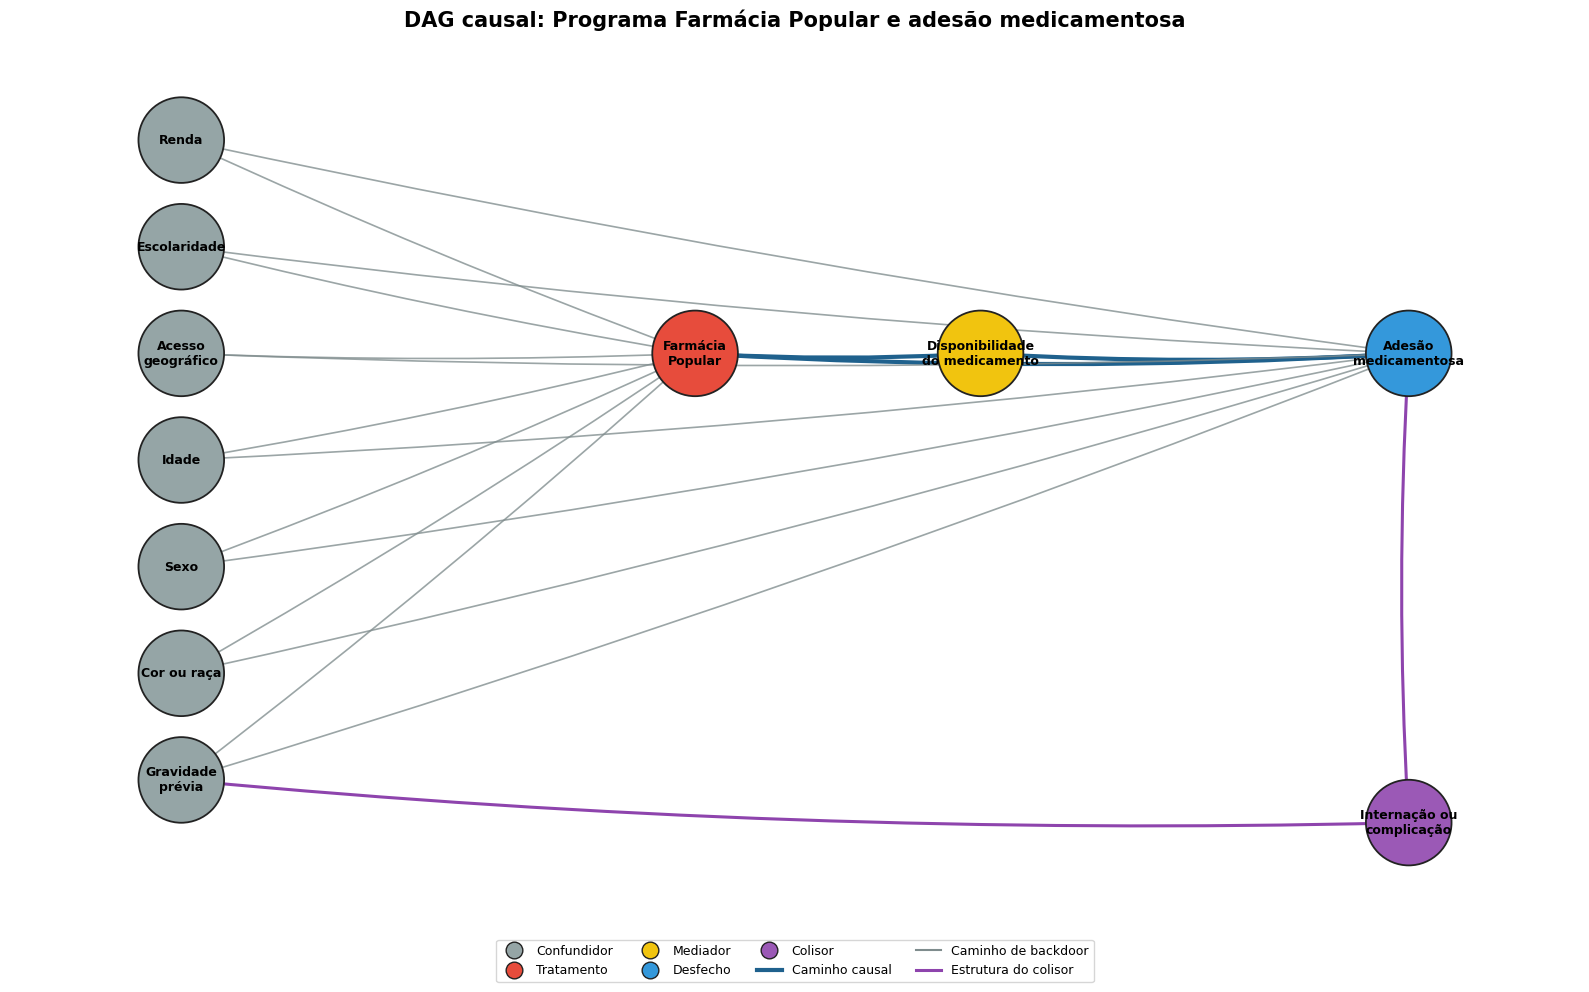

In [ ]:
# ============================================================
# 15. CONSTRUÇÃO DO DAG CAUSAL
# ============================================================
#
# Nesta etapa representaremos graficamente a história causal
# formulada anteriormente.
#
# O DAG mostrará:
#
# - o tratamento: Farmácia Popular;
# - o desfecho: adesão medicamentosa;
# - os confundidores anteriores ao tratamento;
# - o mediador pelo qual o programa pode produzir seu efeito;
# - o colisor que não deve ser controlado.
#
# As setas representam hipóteses causais, e não apenas associações
# estatísticas observadas nos dados.
# ============================================================

from matplotlib.lines import Line2D

dag = nx.DiGraph()

# ------------------------------------------------------------
# Definição dos nós
# ------------------------------------------------------------
#
# Agora identificaremos os elementos centrais da história causal:
# tratamento, desfecho, mediador, colisor e confundidores.
# ------------------------------------------------------------

tratamento = "Farmácia\nPopular"
desfecho = "Adesão\nmedicamentosa"
mediador = "Disponibilidade\ndo medicamento"
colisor = "Internação ou\ncomplicação"

confundidores = [
    "Renda",
    "Escolaridade",
    "Acesso\ngeográfico",
    "Idade",
    "Sexo",
    "Cor ou raça",
    "Gravidade\nprévia"
]

dag.add_nodes_from(
    confundidores
    + [tratamento, mediador, desfecho, colisor]
)

# ------------------------------------------------------------
# Definição dos grupos de arestas
# ------------------------------------------------------------
#
# Separaremos as setas conforme sua função causal. Isso permitirá
# utilizar cores e espessuras diferentes no desenho.
# ------------------------------------------------------------

# Caminhos pelos quais o tratamento pode afetar o desfecho.
arestas_causais = [
    (tratamento, mediador),
    (mediador, desfecho),
    (tratamento, desfecho)
]

# Caminhos de backdoor gerados pelos confundidores.
arestas_confundimento = []

for confundidor in confundidores:
    arestas_confundimento.append((confundidor, tratamento))
    arestas_confundimento.append((confundidor, desfecho))

# Estrutura do colisor:
# Gravidade prévia -> Internação <- Adesão.
arestas_colisor = [
    ("Gravidade\nprévia", colisor),
    (desfecho, colisor)
]

dag.add_edges_from(arestas_causais)
dag.add_edges_from(arestas_confundimento)
dag.add_edges_from(arestas_colisor)

# ------------------------------------------------------------
# Posicionamento dos nós
# ------------------------------------------------------------
#
# Agora organizaremos os nós para facilitar a leitura do DAG.
# Os confundidores ficam à esquerda, o tratamento e o mediador no
# centro, o desfecho à direita e o colisor na parte inferior.
# ------------------------------------------------------------

posicoes = {
    "Renda": (-3.6, 3.0),
    "Escolaridade": (-3.6, 2.0),
    "Acesso\ngeográfico": (-3.6, 1.0),
    "Idade": (-3.6, 0.0),
    "Sexo": (-3.6, -1.0),
    "Cor ou raça": (-3.6, -2.0),
    "Gravidade\nprévia": (-3.6, -3.0),

    tratamento: (0.0, 1.0),
    mediador: (2.0, 1.0),
    desfecho: (5.0, 1.0),
    colisor: (5.0, -3.4),
}

# ------------------------------------------------------------
# Cores dos nós
# ------------------------------------------------------------
#
# Cada cor representa uma função causal distinta.
# ------------------------------------------------------------

cor_tratamento = "#e74c3c"
cor_desfecho = "#3498db"
cor_mediador = "#f1c40f"
cor_colisor = "#9b59b6"
cor_confundidor = "#95a5a6"

cores_nos = []

for no in dag.nodes:

    if no == tratamento:
        cores_nos.append(cor_tratamento)

    elif no == desfecho:
        cores_nos.append(cor_desfecho)

    elif no == mediador:
        cores_nos.append(cor_mediador)

    elif no == colisor:
        cores_nos.append(cor_colisor)

    else:
        cores_nos.append(cor_confundidor)

# ------------------------------------------------------------
# Construção da figura
# ------------------------------------------------------------
#
# Agora desenharemos os nós e, em seguida, cada grupo de setas
# separadamente. Os caminhos causais principais serão destacados.
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(16, 10))

# Nós
nx.draw_networkx_nodes(
    dag,
    posicoes,
    node_color=cores_nos,
    node_size=3800,
    edgecolors="#222222",
    linewidths=1.3,
    ax=ax
)

# Rótulos
nx.draw_networkx_labels(
    dag,
    posicoes,
    font_size=9,
    font_weight="bold",
    ax=ax
)

# Caminhos causais principais
nx.draw_networkx_edges(
    dag,
    posicoes,
    edgelist=arestas_causais,
    arrows=True,
    arrowsize=24,
    arrowstyle="-|>",
    width=3.0,
    edge_color="#1f618d",
    connectionstyle="arc3,rad=0.03",
    ax=ax
)

# Caminhos de confundimento
nx.draw_networkx_edges(
    dag,
    posicoes,
    edgelist=arestas_confundimento,
    arrows=True,
    arrowsize=18,
    arrowstyle="-|>",
    width=1.2,
    edge_color="#7f8c8d",
    alpha=0.78,
    connectionstyle="arc3,rad=0.02",
    ax=ax
)

# Estrutura do colisor
nx.draw_networkx_edges(
    dag,
    posicoes,
    edgelist=arestas_colisor,
    arrows=True,
    arrowsize=22,
    arrowstyle="-|>",
    width=2.2,
    edge_color="#8e44ad",
    connectionstyle="arc3,rad=0.03",
    ax=ax
)

# ------------------------------------------------------------
# Legenda
# ------------------------------------------------------------
#
# A legenda facilita a identificação da função causal de cada nó.
# ------------------------------------------------------------

elementos_legenda = [
    Line2D(
        [0], [0],
        marker="o",
        color="w",
        label="Confundidor",
        markerfacecolor=cor_confundidor,
        markeredgecolor="#222222",
        markersize=12
    ),
    Line2D(
        [0], [0],
        marker="o",
        color="w",
        label="Tratamento",
        markerfacecolor=cor_tratamento,
        markeredgecolor="#222222",
        markersize=12
    ),
    Line2D(
        [0], [0],
        marker="o",
        color="w",
        label="Mediador",
        markerfacecolor=cor_mediador,
        markeredgecolor="#222222",
        markersize=12
    ),
    Line2D(
        [0], [0],
        marker="o",
        color="w",
        label="Desfecho",
        markerfacecolor=cor_desfecho,
        markeredgecolor="#222222",
        markersize=12
    ),
    Line2D(
        [0], [0],
        marker="o",
        color="w",
        label="Colisor",
        markerfacecolor=cor_colisor,
        markeredgecolor="#222222",
        markersize=12
    ),
    Line2D(
        [0], [0],
        color="#1f618d",
        linewidth=3.0,
        label="Caminho causal"
    ),
    Line2D(
        [0], [0],
        color="#7f8c8d",
        linewidth=1.5,
        label="Caminho de backdoor"
    ),
    Line2D(
        [0], [0],
        color="#8e44ad",
        linewidth=2.2,
        label="Estrutura do colisor"
    )
]

ax.legend(
    handles=elementos_legenda,
    loc="upper center",
    bbox_to_anchor=(0.5, -0.03),
    ncol=4,
    frameon=True,
    fontsize=9
)

# ------------------------------------------------------------
# Título e acabamento visual
# ------------------------------------------------------------

ax.set_title(
    "DAG causal: Programa Farmácia Popular e adesão medicamentosa",
    fontsize=15,
    fontweight="bold",
    pad=20
)

ax.set_xlim(-4.8, 6.2)
ax.set_ylim(-4.2, 3.8)

ax.axis("off")
plt.tight_layout()
plt.show()

### Interpretação do DAG

O DAG apresenta o Programa Farmácia Popular como tratamento e a adesão medicamentosa como desfecho.

As variáveis renda, escolaridade, acesso geográfico, idade, sexo, cor ou raça e gravidade prévia foram representadas como confundidores, pois podem influenciar simultaneamente a utilização do programa e a adesão ao tratamento.

A disponibilidade do medicamento foi representada como mediador do efeito da política. A hipótese é que o programa reduza barreiras econômicas e materiais de acesso, aumentando a disponibilidade dos medicamentos e, consequentemente, a adesão. Como o interesse é o efeito total da política, essa variável não deve ser controlada.

A internação ou complicação foi representada como colisor, pois pode ser causada tanto pela gravidade prévia da hipertensão quanto pela adesão medicamentosa. Condicionar a análise a essa variável pode abrir uma associação não causal entre seus determinantes e, por isso, ela também não deve ser incluída no conjunto de ajuste.

As setas do DAG representam hipóteses causais construídas com base no conhecimento substantivo sobre o funcionamento da política, e não relações identificadas automaticamente pelos dados.

# Aplicação do critério de backdoor

## Caminhos de backdoor

O efeito causal de interesse é representado pelo caminho:

\[
\text{Farmácia Popular} \longrightarrow \text{Adesão medicamentosa}
\]

e também pelo caminho mediado:

\[
\text{Farmácia Popular}
\longrightarrow
\text{Disponibilidade do medicamento}
\longrightarrow
\text{Adesão medicamentosa}
\]

Entretanto, como a utilização do Programa Farmácia Popular não é aleatória, existem caminhos não causais que começam com uma seta entrando no tratamento.

Um exemplo é:

\[
\text{Farmácia Popular}
\longleftarrow
\text{Renda}
\longrightarrow
\text{Adesão medicamentosa}
\]

Nesse caminho, a renda influencia simultaneamente a probabilidade de utilização do programa e a adesão ao tratamento. Se esse caminho permanecer aberto, a associação observada entre tratamento e desfecho poderá refletir tanto o efeito do programa quanto diferenças socioeconômicas entre tratados e não tratados.

A mesma lógica se aplica aos demais confundidores:

\[
\text{Farmácia Popular}
\longleftarrow
X
\longrightarrow
\text{Adesão medicamentosa}
\]

em que \(X\) representa idade, sexo, cor ou raça, escolaridade, renda, acesso geográfico e gravidade prévia da hipertensão.

## Conjunto de ajuste proposto

Para identificar o efeito total do Programa Farmácia Popular sobre a adesão medicamentosa, propõe-se controlar as variáveis pré-tratamento que funcionam como causas comuns do tratamento e do desfecho.

O conjunto de ajuste conceitual é:

\[
X =
\{
\text{idade},
\text{sexo},
\text{cor ou raça},
\text{escolaridade},
\text{renda},
\text{acesso geográfico},
\text{gravidade prévia}
\}
\]

Essas variáveis bloqueiam os caminhos de backdoor entre o tratamento e o desfecho.

Na PNS 2019, parte desse conjunto pode ser operacionalizada pelas seguintes variáveis:

- idade: `C008`;
- sexo: `C006`;
- cor ou raça: `C009`;
- escolaridade: `VDD004A`;
- renda domiciliar per capita: `VDF003`;
- localização geográfica: `V0001`.

A gravidade prévia da hipertensão exigiria uma medida clínica anterior à utilização do programa. Caso essa informação não esteja disponível de forma adequada, permanecerá a possibilidade de confundimento residual.

## Variáveis que devem ser controladas

Devem ser controladas as variáveis que:

1. antecedem o tratamento;
2. influenciam a probabilidade de utilizar o Farmácia Popular;
3. também influenciam a adesão medicamentosa;
4. não são consequências do tratamento.

Assim, devem ser consideradas no ajuste:

- renda;
- escolaridade;
- acesso geográfico;
- idade;
- sexo;
- cor ou raça;
- gravidade prévia da hipertensão.

## Variáveis que não devem ser controladas

### Mediador: disponibilidade do medicamento

A disponibilidade do medicamento está no caminho causal:

\[
\text{Farmácia Popular}
\longrightarrow
\text{Disponibilidade}
\longrightarrow
\text{Adesão}
\]

Como o objetivo é estimar o **efeito total** da política, essa variável não deve ser controlada.

Seu ajuste bloquearia parte do efeito produzido pelo programa e resultaria em uma estimativa do efeito direto, excluindo o mecanismo de ampliação do acesso.

### Colisor: internação ou complicação

A internação ou complicação recebe setas da gravidade prévia e da adesão:

\[
\text{Gravidade prévia}
\longrightarrow
\text{Internação}
\longleftarrow
\text{Adesão medicamentosa}
\]

Esse nó é um colisor.

Sem condicionamento, o caminho permanece fechado. Entretanto, controlar a internação, estratificar por essa variável ou restringir a amostra a pessoas internadas abriria uma associação não causal entre gravidade prévia e adesão.

Por isso, a internação ou complicação posterior ao tratamento não deve ser incluída no conjunto de ajuste.

### Variáveis posteriores ao tratamento

Também não devem ser controladas variáveis que sejam consequências da utilização do programa, como:

- disponibilidade posterior do medicamento;
- redução de gastos com medicamentos;
- continuidade posterior do tratamento;
- melhora clínica posterior;
- internações posteriores;
- complicações posteriores.

O ajuste por variáveis pós-tratamento pode bloquear mecanismos causais ou introduzir viés.

## Critério de backdoor

Um conjunto de variáveis satisfaz o critério de backdoor quando:

1. nenhum de seus elementos é descendente do tratamento; e
2. o conjunto bloqueia todos os caminhos entre tratamento e desfecho que começam com uma seta entrando no tratamento.

No DAG proposto, o ajuste pelos confundidores pré-tratamento bloqueia os caminhos de backdoor, enquanto mediadores e colisores permanecem fora do conjunto de ajuste.

## Síntese da estratégia de controle

| Tipo de variável | Exemplo | Controlar? | Justificativa |
|---|---|---:|---|
| Confundidor | Renda | Sim | Causa comum do tratamento e do desfecho |
| Confundidor | Escolaridade | Sim | Influencia utilização do programa e adesão |
| Confundidor | Idade | Sim | Pode afetar tratamento e desfecho |
| Confundidor | Acesso geográfico | Sim | Influencia disponibilidade do programa e continuidade do cuidado |
| Mediador | Disponibilidade do medicamento | Não | Está no mecanismo causal da política |
| Colisor | Internação ou complicação | Não | Seu controle pode abrir caminho espúrio |
| Desfecho | Adesão medicamentosa | Não | É a variável de resultado |
| Variável pós-tratamento | Melhora clínica | Não | Pode ser consequência do tratamento |

## Conclusão

O conjunto de ajuste deve ser formado por confundidores anteriores ao tratamento. O mediador deve permanecer sem controle para preservar o efeito total do Programa Farmácia Popular, enquanto o colisor não deve ser condicionado para evitar a abertura de associações não causais.

Dessa forma, o DAG não apenas representa a história causal, mas orienta diretamente a escolha das variáveis que devem e que não devem ser incluídas na análise.

#**CONSIDERAÇÕES FINAIS**

Este trabalho aplicou os conceitos fundamentais de inferência causal a uma política pública, utilizando o Programa Farmácia Popular como estudo de caso. A partir dos microdados da PNS 2019, foi construída uma base analítica composta por indivíduos diagnosticados com hipertensão arterial e com prescrição de medicamentos. Em seguida, foram definidos o tratamento, o desfecho, o estimando de interesse e a história causal que fundamentou a construção do DAG. Por fim, aplicou-se o critério de backdoor para justificar o conjunto de ajuste, distinguindo confundidores, mediadores e colisores. Embora a estrutura do questionário da PNS imponha limitações para a identificação empírica do efeito causal do programa, o exercício permitiu demonstrar a aplicação dos principais conceitos de inferência causal em um contexto de avaliação de políticas públicas.